In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("campaign_responses.csv")

In [3]:
df.head(5)

,customer_id,age,gender,annual_income,credit_score,employed,marital_status,no_of_children,responded
0,1,35,Male,65000,720,Yes,Married,2,Yes
1,2,28,Female,45000,680,No,Single,0,No
2,3,42,Male,85000,750,Yes,Married,3,Yes
3,4,31,Female,55000,710,Yes,Single,1,No
4,5,47,Male,95000,790,Yes,Married,2,Yes


In [4]:
df.tail(5)

,customer_id,age,gender,annual_income,credit_score,employed,marital_status,no_of_children,responded
51,52,31,Female,50000,680,Yes,Single,0,No
52,53,46,Male,98000,800,Yes,Married,3,Yes
53,54,28,Female,42000,630,No,Single,0,No
54,55,41,Male,90000,770,Yes,Married,2,Yes
55,56,34,Female,60000,710,Yes,Single,1,No


In [5]:
df.shape

(56, 9)

In [6]:
# Display basic info
print("Initial Dataset Info:")
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     56 non-null     int64 
 1   age             56 non-null     int64 
 2   gender          56 non-null     object
 3   annual_income   56 non-null     int64 
 4   credit_score    56 non-null     int64 
 5   employed        56 non-null     object
 6   marital_status  56 non-null     object
 7   no_of_children  56 non-null     int64 
 8   responded       56 non-null     object
dtypes: int64(5), object(4)
memory usage: 4.1+ KB
None

Missing values per column:
 customer_id       0
age               0
gender            0
annual_income     0
credit_score      0
employed          0
marital_status    0
no_of_children    0
responded         0
dtype: int64


In [7]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]


In [8]:
num_cols = ['age', 'annual_income', 'credit_score', 'no_of_children']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    after = len(df)
    print(f"Removed {before - after} outliers from {col}")


Removed 0 outliers from age
Removed 0 outliers from annual_income
Removed 0 outliers from credit_score
Removed 0 outliers from no_of_children


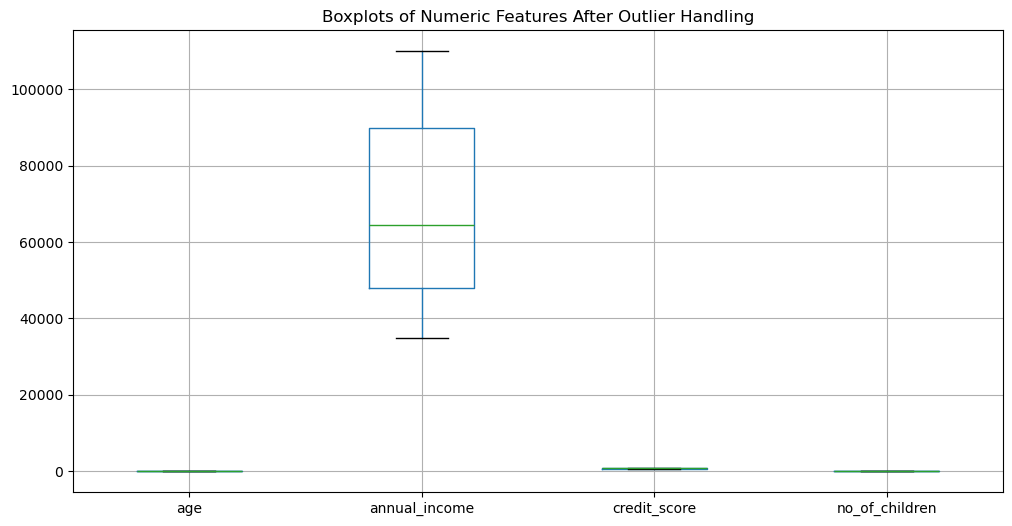

In [9]:
plt.figure(figsize=(12,6))
df[num_cols].boxplot()
plt.title("Boxplots of Numeric Features After Outlier Handling")
plt.show()


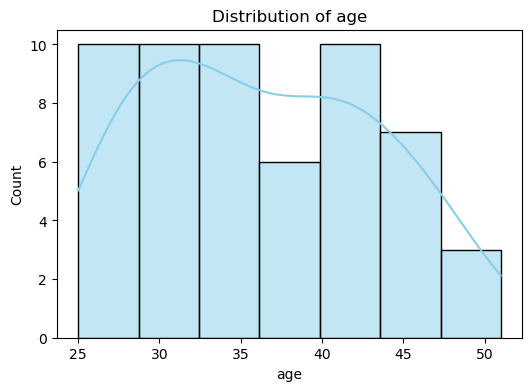

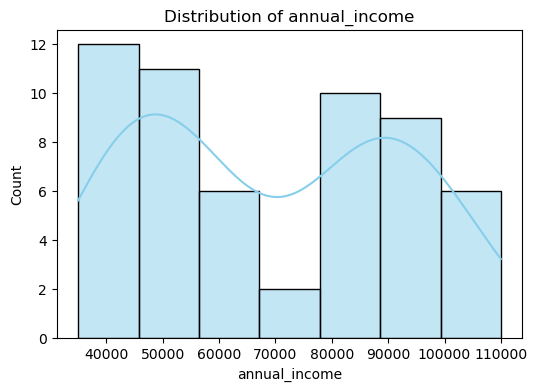

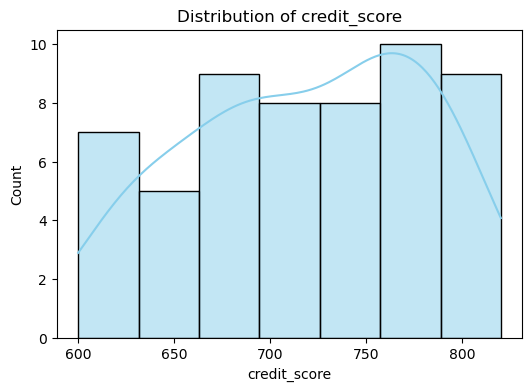

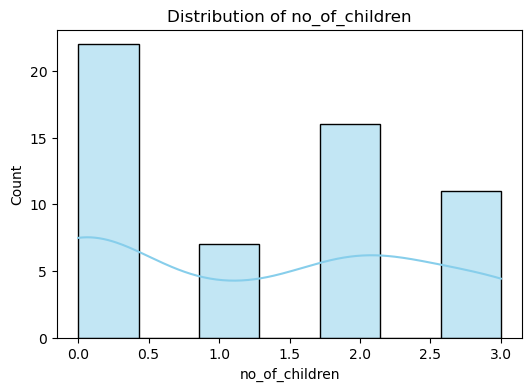

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()


In [11]:
print("Statistical Summary After Cleaning:")
print(df[num_cols].describe())


Statistical Summary After Cleaning:
             age  annual_income  credit_score  no_of_children
count  56.000000      56.000000     56.000000       56.000000
mean   36.214286   69017.857143    719.107143        1.285714
std     7.088311   22784.756524     60.340753        1.186504
min    25.000000   35000.000000    600.000000        0.000000
25%    30.000000   48000.000000    677.500000        0.000000
50%    35.500000   64500.000000    720.000000        1.000000
75%    42.000000   90000.000000    770.000000        2.000000
max    51.000000  110000.000000    820.000000        3.000000


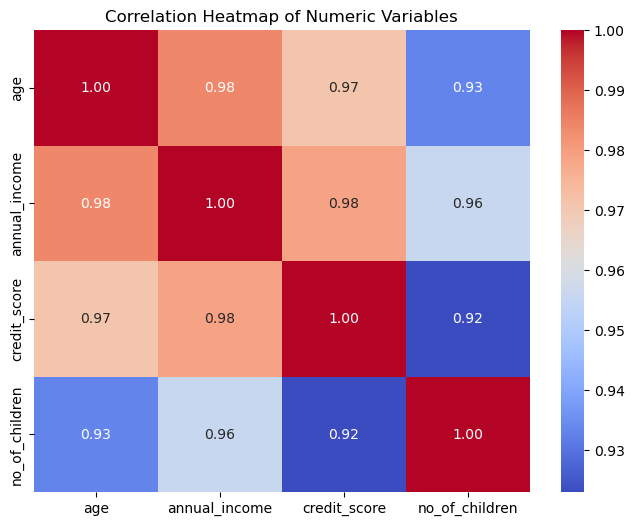

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


STEP 2

In [13]:
# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\n Categorical Features:")
print(categorical_features)


Numerical Features:
['customer_id', 'age', 'annual_income', 'credit_score', 'no_of_children']

 Categorical Features:
['gender', 'employed', 'marital_status', 'responded']


In [14]:
# 1. Age Grouping (helps model detect age patterns)
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 25, 40, 60, 100],
                         labels=['Young', 'Adult', 'Middle_Aged', 'Senior'])

# 2. Income per Child (useful for spending/credit analysis)
df['income_per_child'] = df['annual_income'] / (df['no_of_children'] + 1)

# 3. Credit Risk Ratio (lower ratio = better credit behavior)
df['credit_risk_ratio'] = df['credit_score'] / df['annual_income']

# 4. Employment Flag (convert 'employed' to numeric flag)
df['employed_flag'] = df['employed'].apply(lambda x: 1 if x == 'Yes' else 0)

# 5. Marital Status Numeric (to measure relation with response)
df['married_flag'] = df['marital_status'].apply(lambda x: 1 if x == 'Married' else 0)

# 6. Age-Weighted Income (to mix experience + income effect)
df['age_income_index'] = df['age'] * df['annual_income']


In [15]:
df.head(5)

,customer_id,age,gender,annual_income,credit_score,employed,marital_status,no_of_children,responded,age_group,income_per_child,credit_risk_ratio,employed_flag,married_flag,age_income_index
0,1,35,Male,65000,720,Yes,Married,2,Yes,Adult,21666.666667,0.011077,1,1,2275000
1,2,28,Female,45000,680,No,Single,0,No,Adult,45000.000000,0.015111,0,0,1260000
2,3,42,Male,85000,750,Yes,Married,3,Yes,Middle_Aged,21250.000000,0.008824,1,1,3570000
3,4,31,Female,55000,710,Yes,Single,1,No,Adult,27500.000000,0.012909,1,0,1705000
4,5,47,Male,95000,790,Yes,Married,2,Yes,Middle_Aged,31666.666667,0.008316,1,1,4465000


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))


In [17]:
corr = df.corr(numeric_only=True)

print("Correlation Matrix:\n", corr)

Correlation Matrix:
                    customer_id       age    gender  annual_income  \
customer_id           1.000000  0.038532 -0.030934       0.070627   
age                   0.038532  1.000000  0.859209       0.983787   
gender               -0.030934  0.859209  1.000000       0.910239   
annual_income         0.070627  0.983787  0.910239       1.000000   
credit_score          0.034086  0.970942  0.863002       0.978764   
employed              0.058877  0.691117  0.549841       0.680372   
marital_status        0.030934 -0.859209 -1.000000      -0.910239   
no_of_children        0.013154  0.932992  0.911185       0.955499   
responded            -0.030934  0.859209  1.000000       0.910239   
income_per_child      0.050308 -0.677463 -0.764143      -0.719384   
credit_risk_ratio    -0.085617 -0.959423 -0.899518      -0.978527   
employed_flag         0.058877  0.691117  0.549841       0.680372   
married_flag         -0.030934  0.859209  1.000000       0.910239   
age_income_in

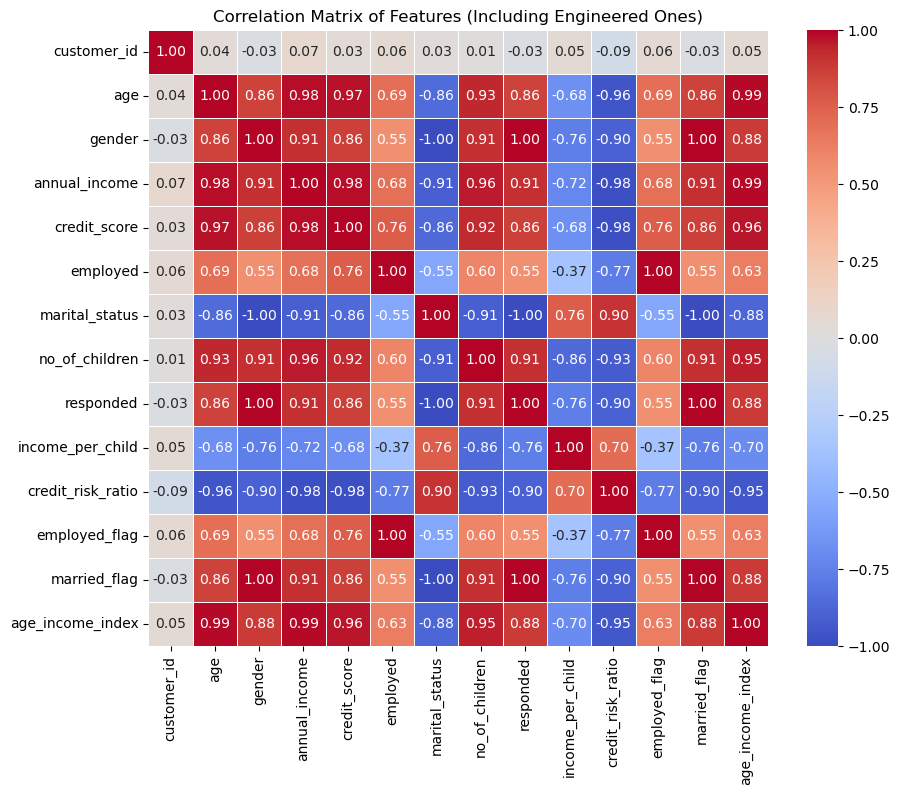

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features (Including Engineered Ones)")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7228\3366898817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')


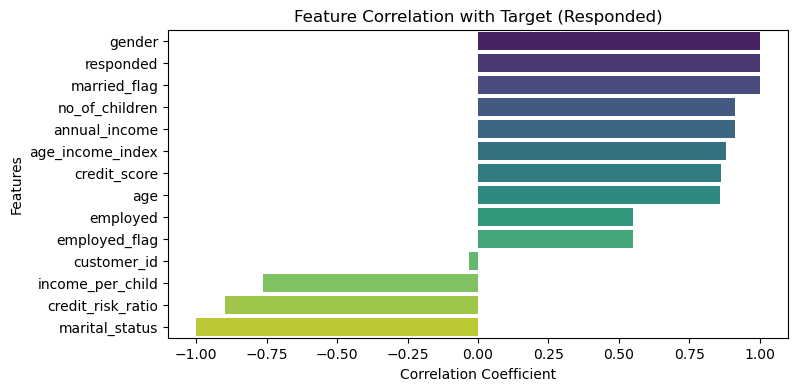

In [19]:
plt.figure(figsize=(8,4))
corr_target = corr['responded'].sort_values(ascending=False)
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title("Feature Correlation with Target (Responded)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()


In [20]:
df.head(5)

,customer_id,age,gender,annual_income,credit_score,employed,marital_status,no_of_children,responded,age_group,income_per_child,credit_risk_ratio,employed_flag,married_flag,age_income_index
0,1,35,1,65000,720,1,0,2,1,Adult,21666.666667,0.011077,1,1,2275000
1,2,28,0,45000,680,0,1,0,0,Adult,45000.000000,0.015111,0,0,1260000
2,3,42,1,85000,750,1,0,3,1,Middle_Aged,21250.000000,0.008824,1,1,3570000
3,4,31,0,55000,710,1,1,1,0,Adult,27500.000000,0.012909,1,0,1705000
4,5,47,1,95000,790,1,0,2,1,Middle_Aged,31666.666667,0.008316,1,1,4465000


STEP 3

In [21]:
df.columns

Index(['customer_id', 'age', 'gender', 'annual_income', 'credit_score',
       'employed', 'marital_status', 'no_of_children', 'responded',
       'age_group', 'income_per_child', 'credit_risk_ratio', 'employed_flag',
       'married_flag', 'age_income_index'],
      dtype='object')

In [22]:
features = ['customer_id', 'age', 'gender', 'annual_income', 'credit_score',
       'employed', 'marital_status', 'no_of_children']
X = df[features]
y = df['responded']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Random forest regresssion
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("RandomForestClassifierr")
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print("Accuracy_score:", acc)

RandomForestClassifierr
Accuracy_score: 1.0


In [25]:
# GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

model = GradientBoostingClassifier()
model.fit(X_train, y_train)
print("GradientBoostingClassifier")
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print("Accuracy_score:", acc)

GradientBoostingClassifier
Accuracy_score: 1.0


In [26]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print("DecisionTreeClassifier")
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print("Accuracy_score:", acc)

DecisionTreeClassifier
Accuracy_score: 0.8333333333333334


In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print("LogisticRegression")
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print("Accuracy_score:", acc)

LogisticRegression
Accuracy_score: 0.9166666666666666


In [29]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model.fit(X_train, y_train)
print("AdaBoostClassifier")
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print("Accuracy_score:", acc)

AdaBoostClassifier
Accuracy_score: 1.0


STEP 4

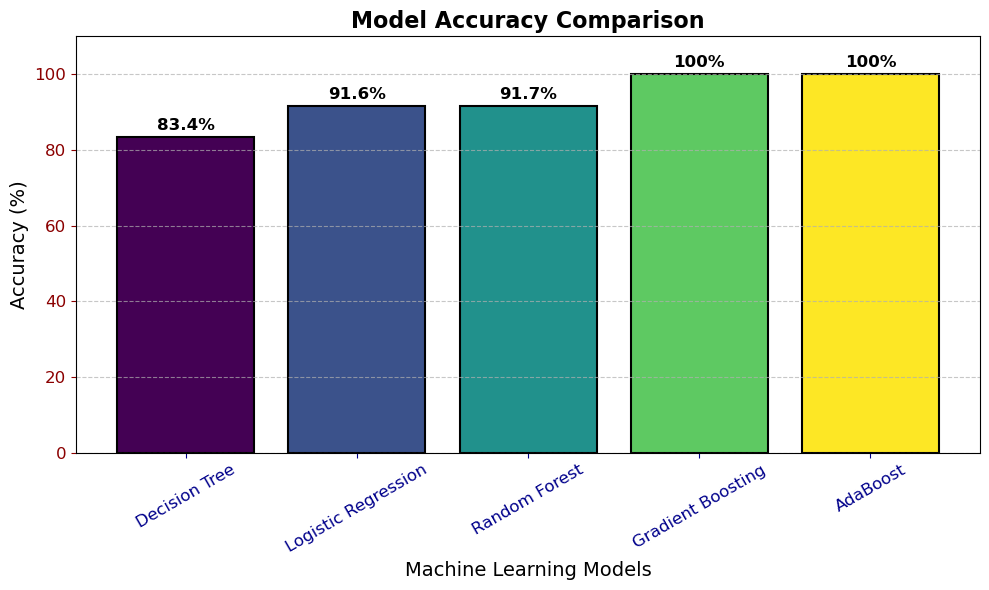

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and their corresponding accuracies
models = ['Decision Tree', 'Logistic Regression', 'Random Forest', 'Gradient Boosting', 'AdaBoost']
accuracies = [ 83.4, 91.6, 91.7, 100, 100]

# Advanced plot setup
fig, ax = plt.subplots(figsize=(10, 6))

# Bar colors with a gradient effect
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

# Bar plot
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Add accuracy text on top of the bars
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{accuracy}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Enhancing plot with grid, labels, and title
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 110)

ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_xlabel('Machine Learning Models', fontsize=14)

# Customize ticks
ax.tick_params(axis='x', rotation=30, labelsize=12, colors='darkblue')
ax.tick_params(axis='y', labelsize=12, colors='darkred')

plt.tight_layout()
plt.show()
